1. Understanding Of The Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/flight.csv')

In [ ]:
print(data.head())

   MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE GENDER  FFP_TIER    WORK_CITY  \
0      54993  11/2/2006        12/24/2008   Male         6            .   
1      28065  2/19/2007          8/3/2007   Male         6          NaN   
2      55106   2/1/2007         8/30/2007   Male         6            .   
3      21189  8/22/2008         8/23/2008   Male         5  Los Angeles   
4      39546  4/10/2009         4/15/2009   Male         6      guiyang   

  WORK_PROVINCE WORK_COUNTRY   AGE  LOAD_TIME  ...  SUM_YR_2  SEG_KM_SUM  \
0       beijing           CN  31.0  3/31/2014  ...  234188.0      580717   
1       beijing           CN  42.0  3/31/2014  ...  167434.0      293678   
2       beijing           CN  40.0  3/31/2014  ...  164982.0      283712   
3            CA           US  64.0  3/31/2014  ...  125500.0      281336   
4       guizhou           CN  48.0  3/31/2014  ...  130702.0      309928   

   LAST_FLIGHT_DATE  LAST_TO_END  AVG_INTERVAL MAX_INTERVAL  EXCHANGE_COUNT  \
0         3/3

In [ ]:
print(data.tail())

       MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE  GENDER  FFP_TIER  WORK_CITY  \
62983      18375  5/20/2011          6/5/2013  Female         4  guangzhou   
62984      36041   3/8/2010         9/14/2013    Male         4     foshan   
62985      45690  3/30/2006         12/2/2006  Female         4  guangzhou   
62986      61027   2/6/2013         2/14/2013  Female         4  guangzhou   
62987      61340  2/17/2013         2/17/2013  Female         4   shanghai   

      WORK_PROVINCE WORK_COUNTRY   AGE  LOAD_TIME  ...  SUM_YR_2  SEG_KM_SUM  \
62983     guangdong           CN  25.0  3/31/2014  ...       0.0        1134   
62984     guangdong           CN  38.0  3/31/2014  ...       0.0        8016   
62985     guangdong           CN  43.0  3/31/2014  ...       0.0        2594   
62986     guangdong           CN  36.0  3/31/2014  ...       0.0        3934   
62987             .           CN  29.0  3/31/2014  ...       0.0        4222   

       LAST_FLIGHT_DATE  LAST_TO_END  AVG_INTERVAL

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

In [ ]:
print(data.shape)

(62988, 23)


In [ ]:
print(data.describe())

          MEMBER_NO      FFP_TIER           AGE  FLIGHT_COUNT         BP_SUM  \
count  62988.000000  62988.000000  62568.000000  62988.000000   62988.000000   
mean   31494.500000      4.102162     42.476346     11.839414   10925.081254   
std    18183.213715      0.373856      9.885915     14.049471   16339.486151   
min        1.000000      4.000000      6.000000      2.000000       0.000000   
25%    15747.750000      4.000000     35.000000      3.000000    2518.000000   
50%    31494.500000      4.000000     41.000000      7.000000    5700.000000   
75%    47241.250000      4.000000     48.000000     15.000000   12831.000000   
max    62988.000000      6.000000    110.000000    213.000000  505308.000000   

            SUM_YR_1       SUM_YR_2     SEG_KM_SUM   LAST_TO_END  \
count   62437.000000   62850.000000   62988.000000  62988.000000   
mean     5355.376064    5604.026014   17123.878691    176.120102   
std      8109.450147    8703.364247   20960.844623    183.822223   
min    

2. Data Preprocessing

In [ ]:
data.isnull().sum()

,0
MEMBER_NO,0
FFP_DATE,0
FIRST_FLIGHT_DATE,0
GENDER,3
FFP_TIER,0
WORK_CITY,2269
WORK_PROVINCE,3248
WORK_COUNTRY,26
AGE,420
LOAD_TIME,0


In [ ]:
data[data.duplicated()]



,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight


In [ ]:
missing_values = ["n/a", "na", "--", "Nan", " ", "."]
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/flight.csv', na_values = missing_values)
print(df)

       MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE  GENDER  FFP_TIER    WORK_CITY  \
0          54993  11/2/2006        12/24/2008    Male         6          NaN   
1          28065  2/19/2007          8/3/2007    Male         6          NaN   
2          55106   2/1/2007         8/30/2007    Male         6          NaN   
3          21189  8/22/2008         8/23/2008    Male         5  Los Angeles   
4          39546  4/10/2009         4/15/2009    Male         6      guiyang   
...          ...        ...               ...     ...       ...          ...   
62983      18375  5/20/2011          6/5/2013  Female         4    guangzhou   
62984      36041   3/8/2010         9/14/2013    Male         4       foshan   
62985      45690  3/30/2006         12/2/2006  Female         4    guangzhou   
62986      61027   2/6/2013         2/14/2013  Female         4    guangzhou   
62987      61340  2/17/2013         2/17/2013  Female         4     shanghai   

      WORK_PROVINCE WORK_COUNTRY   AGE 

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])
df

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993.0,11/2/2006,12/24/2008,Male,6.0,NaN,beijing,CN,31.0,3/31/2014,...,234188.0,580717.0,3/31/2014,1.0,3.483254,18.0,34.0,0.961639,619760.0,50.0
1,28065.0,2/19/2007,8/3/2007,Male,6.0,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678.0,3/25/2014,7.0,5.194245,17.0,29.0,1.252314,415768.0,33.0
2,55106.0,2/1/2007,8/30/2007,Male,6.0,NaN,beijing,CN,40.0,3/31/2014,...,164982.0,283712.0,3/21/2014,11.0,5.298507,18.0,20.0,1.254676,406361.0,26.0
3,21189.0,8/22/2008,8/23/2008,Male,5.0,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336.0,12/26/2013,97.0,27.863636,73.0,11.0,1.090870,372204.0,12.0
4,39546.0,4/10/2009,4/15/2009,Male,6.0,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928.0,3/27/2014,5.0,4.788079,47.0,27.0,0.970658,338813.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62983,18375.0,5/20/2011,6/5/2013,Female,4.0,guangzhou,guangdong,CN,25.0,3/31/2014,...,0.0,1134.0,6/9/2013,297.0,4.000000,4.0,1.0,0.000000,12318.0,22.0
62984,36041.0,3/8/2010,9/14/2013,Male,4.0,foshan,guangdong,CN,38.0,3/31/2014,...,0.0,8016.0,1/3/2014,89.0,37.000000,60.0,14.0,0.000000,106972.0,43.0
62985,45690.0,3/30/2006,12/2/2006,Female,4.0,guangzhou,guangdong,CN,43.0,3/31/2014,...,0.0,2594.0,3/3/2014,29.0,166.000000,166.0,0.0,0.000000,0.0,0.0
62986,61027.0,2/6/2013,2/14/2013,Female,4.0,guangzhou,guangdong,CN,36.0,3/31/2014,...,0.0,3934.0,2/26/2013,400.0,12.000000,12.0,0.0,0.000000,0.0,0.0


In [ ]:
df.isnull().sum()

,0
MEMBER_NO,0
FFP_DATE,0
FIRST_FLIGHT_DATE,0
GENDER,3
FFP_TIER,0
WORK_CITY,2938
WORK_PROVINCE,4181
WORK_COUNTRY,26
AGE,0
LOAD_TIME,0


In [ ]:
df.loc[62987,'WORK_PROVINCE'] = 'shanghai'
print(df)

       MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE  GENDER  FFP_TIER    WORK_CITY  \
0        54993.0  11/2/2006        12/24/2008    Male       6.0          NaN   
1        28065.0  2/19/2007          8/3/2007    Male       6.0          NaN   
2        55106.0   2/1/2007         8/30/2007    Male       6.0          NaN   
3        21189.0  8/22/2008         8/23/2008    Male       5.0  Los Angeles   
4        39546.0  4/10/2009         4/15/2009    Male       6.0      guiyang   
...          ...        ...               ...     ...       ...          ...   
62983    18375.0  5/20/2011          6/5/2013  Female       4.0    guangzhou   
62984    36041.0   3/8/2010         9/14/2013    Male       4.0       foshan   
62985    45690.0  3/30/2006         12/2/2006  Female       4.0    guangzhou   
62986    61027.0   2/6/2013         2/14/2013  Female       4.0    guangzhou   
62987    61340.0  2/17/2013         2/17/2013  Female       4.0     shanghai   

      WORK_PROVINCE WORK_COUNTRY   AGE 

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['WORK_Country_encoded'] = encoder.fit_transform(df['WORK_COUNTRY'])

print(df)

       MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE  GENDER  FFP_TIER    WORK_CITY  \
0        54993.0  11/2/2006        12/24/2008    Male       6.0          NaN   
1        28065.0  2/19/2007          8/3/2007    Male       6.0          NaN   
2        55106.0   2/1/2007         8/30/2007    Male       6.0          NaN   
3        21189.0  8/22/2008         8/23/2008    Male       5.0  Los Angeles   
4        39546.0  4/10/2009         4/15/2009    Male       6.0      guiyang   
...          ...        ...               ...     ...       ...          ...   
62983    18375.0  5/20/2011          6/5/2013  Female       4.0    guangzhou   
62984    36041.0   3/8/2010         9/14/2013    Male       4.0       foshan   
62985    45690.0  3/30/2006         12/2/2006  Female       4.0    guangzhou   
62986    61027.0   2/6/2013         2/14/2013  Female       4.0    guangzhou   
62987    61340.0  2/17/2013         2/17/2013  Female       4.0     shanghai   

      WORK_PROVINCE WORK_COUNTRY   AGE 

In [ ]:
df = pd.get_dummies(df, columns=['GENDER'], drop_first=False)
print(df)

       MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE  FFP_TIER    WORK_CITY  \
0        54993.0  11/2/2006        12/24/2008       6.0          NaN   
1        28065.0  2/19/2007          8/3/2007       6.0          NaN   
2        55106.0   2/1/2007         8/30/2007       6.0          NaN   
3        21189.0  8/22/2008         8/23/2008       5.0  Los Angeles   
4        39546.0  4/10/2009         4/15/2009       6.0      guiyang   
...          ...        ...               ...       ...          ...   
62983    18375.0  5/20/2011          6/5/2013       4.0    guangzhou   
62984    36041.0   3/8/2010         9/14/2013       4.0       foshan   
62985    45690.0  3/30/2006         12/2/2006       4.0    guangzhou   
62986    61027.0   2/6/2013         2/14/2013       4.0    guangzhou   
62987    61340.0  2/17/2013         2/17/2013       4.0     shanghai   

      WORK_PROVINCE WORK_COUNTRY   AGE  LOAD_TIME  FLIGHT_COUNT  ...  \
0           beijing           CN  31.0  3/31/2014         210.0

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Scaled_Flight_Count'] = scaler.fit_transform(df[['FLIGHT_COUNT']])
print(df)

       MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE  FFP_TIER    WORK_CITY  \
0        54993.0  11/2/2006        12/24/2008       6.0          NaN   
1        28065.0  2/19/2007          8/3/2007       6.0          NaN   
2        55106.0   2/1/2007         8/30/2007       6.0          NaN   
3        21189.0  8/22/2008         8/23/2008       5.0  Los Angeles   
4        39546.0  4/10/2009         4/15/2009       6.0      guiyang   
...          ...        ...               ...       ...          ...   
62983    18375.0  5/20/2011          6/5/2013       4.0    guangzhou   
62984    36041.0   3/8/2010         9/14/2013       4.0       foshan   
62985    45690.0  3/30/2006         12/2/2006       4.0    guangzhou   
62986    61027.0   2/6/2013         2/14/2013       4.0    guangzhou   
62987    61340.0  2/17/2013         2/17/2013       4.0     shanghai   

      WORK_PROVINCE WORK_COUNTRY   AGE  LOAD_TIME  FLIGHT_COUNT  ...  \
0           beijing           CN  31.0  3/31/2014         210.0

3. Exploratory Data Analysis

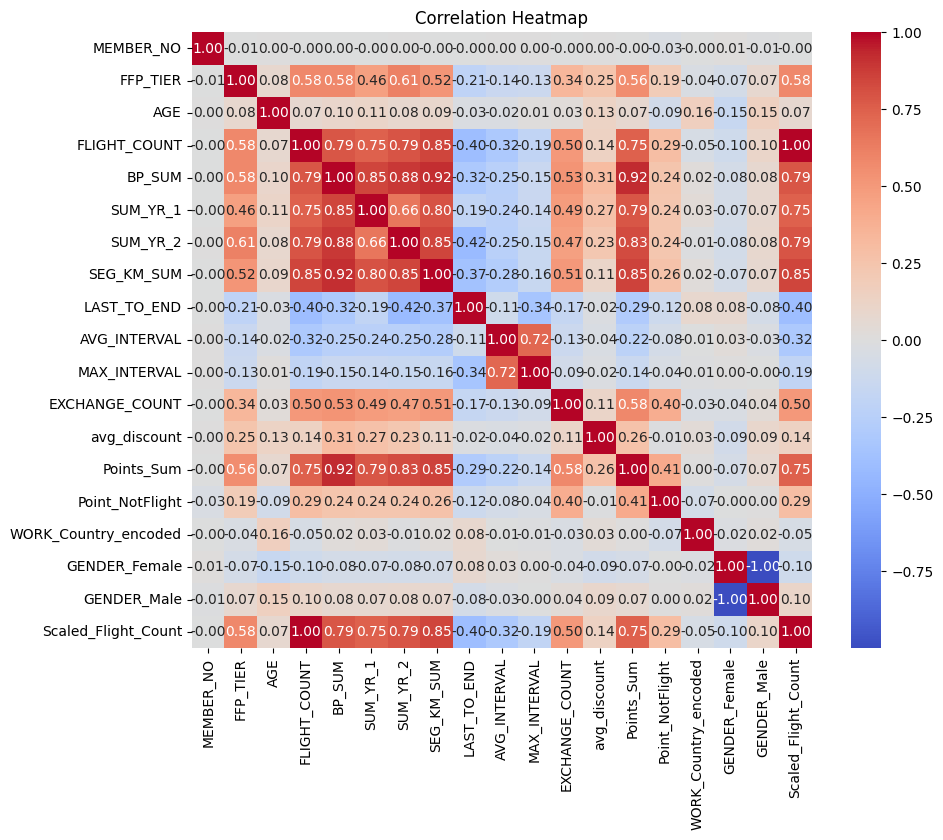

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

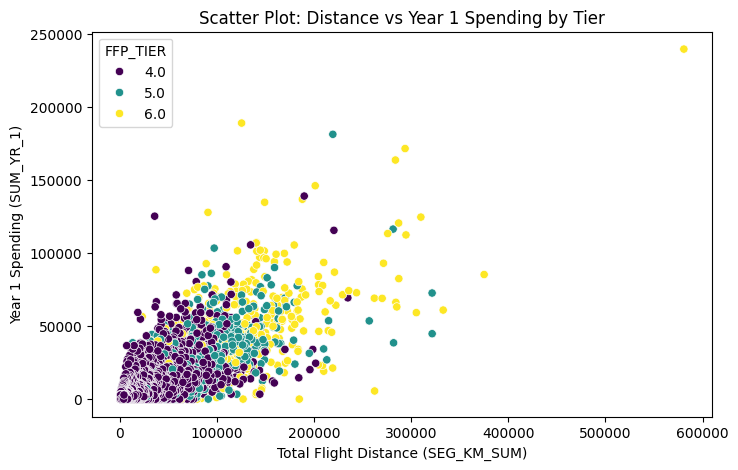

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='SEG_KM_SUM', y='SUM_YR_1', hue='FFP_TIER', palette='viridis')
plt.title('Scatter Plot: Distance vs Year 1 Spending by Tier')
plt.xlabel('Total Flight Distance (SEG_KM_SUM)')
plt.ylabel('Year 1 Spending (SUM_YR_1)')
plt.show()


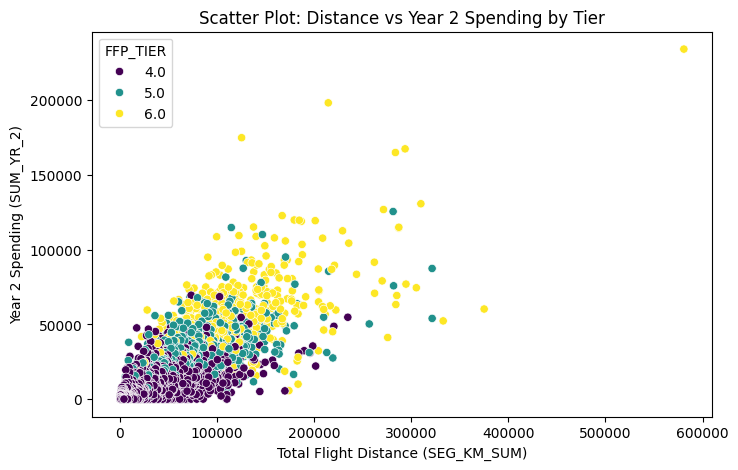

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='SEG_KM_SUM', y='SUM_YR_2', hue='FFP_TIER', palette='viridis')
plt.title('Scatter Plot: Distance vs Year 2 Spending by Tier')
plt.xlabel('Total Flight Distance (SEG_KM_SUM)')
plt.ylabel('Year 2 Spending (SUM_YR_2)')
plt.show()

<Axes: xlabel='SEG_KM_SUM', ylabel='FFP_TIER'>

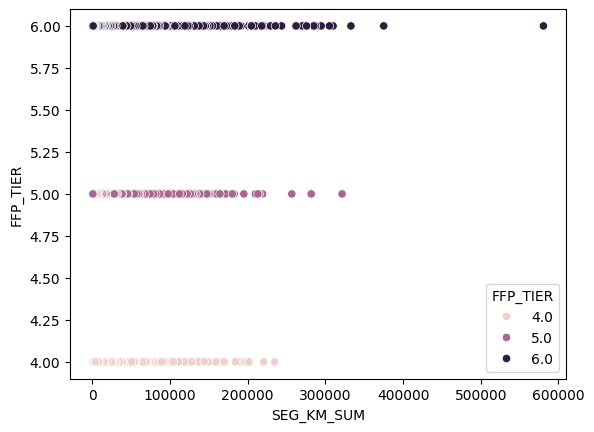

In [ ]:
sns.scatterplot(x='SEG_KM_SUM', y='FFP_TIER', hue='FFP_TIER', data=df)


4. Model Development and Evaluation

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
features = ['Scaled_Flight_Count', 'SEG_KM_SUM', 'SUM_YR_1', 'SUM_YR_2','BP_SUM']
X_scaled = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
df['cluster']

,cluster
0,2
1,2
2,2
3,2
4,2
...,...
62983,0
62984,0
62985,0
62986,0


In [ ]:
cluster_map = {0: 4, 1: 5, 2: 6}

df['cluster_mapped'] = df['cluster'].map(cluster_map)
df['cluster_mapped']

,cluster_mapped
0,6
1,6
2,6
3,6
4,6
...,...
62983,4
62984,4
62985,4
62986,4


In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df['cluster_mapped'])
print("Silhouette Score:", score)

Silhouette Score: 0.6203425165528782


In [ ]:
mismatch_df = df[df['FFP_TIER'] != df['cluster_mapped']]
mismatch_count = len(mismatch_df)

total_rows = len(df)

mismatch_percentage = (mismatch_count / total_rows) * 100

print(f"Mismatched rows: {mismatch_count}")
print(f"Total rows: {total_rows}")
print(f"Mismatch Percentage: {mismatch_percentage:.2f}%")

Mismatched rows: 10812
Total rows: 62988
Mismatch Percentage: 17.17%


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df_unclean = df.copy()
X_unclean = df_unclean[features]
y_unclean = df_unclean['FFP_TIER']

df_clean = df.drop(mismatch_df.index)

X_clean = df_clean[features]
y_clean = df_clean['cluster_mapped']

In [ ]:
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_unclean, y_unclean, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

In [ ]:

X_train_u_scaled = scaler.fit_transform(X_train_u)
X_test_u_scaled = scaler.transform(X_test_u)

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)


In [ ]:
logreg_unclean = LogisticRegression(max_iter=1000, random_state=42)
logreg_unclean.fit(X_train_u_scaled, y_train_u)

logreg_clean = LogisticRegression(max_iter=1000, random_state=42)
logreg_clean.fit(X_train_c_scaled, y_train_c)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_unclean = logreg_unclean.predict(X_test_u_scaled)
y_pred_clean = logreg_clean.predict(X_test_c_scaled)

print("UNCLEAN DATASET (FFP_TIER) RESULTS")
print(classification_report(y_test_u, y_pred_unclean))
print("Accuracy:", accuracy_score(y_test_u, y_pred_unclean))

print("\nCLEAN DATASET (CLUSTER_MAPPED) RESULTS")
print(classification_report(y_test_c, y_pred_clean))
print("Accuracy:", accuracy_score(y_test_c, y_pred_clean))

UNCLEAN DATASET (FFP_TIER) RESULTS
              precision    recall  f1-score   support

         4.0       0.96      0.99      0.98     11639
         5.0       0.58      0.41      0.48       641
         6.0       0.72      0.19      0.30       318

    accuracy                           0.94     12598
   macro avg       0.75      0.53      0.59     12598
weighted avg       0.93      0.94      0.93     12598

Accuracy: 0.9432449595173837

CLEAN DATASET (CLUSTER_MAPPED) RESULTS
              precision    recall  f1-score   support

           4       1.00      1.00      1.00      9868
           5       1.00      0.98      0.99       438
           6       1.00      1.00      1.00       130

    accuracy                           1.00     10436
   macro avg       1.00      0.99      1.00     10436
weighted avg       1.00      1.00      1.00     10436

Accuracy: 0.9993292449214258
